# Trader Performance vs Market Sentiment Analysis

## Primetrade.ai — Data Science Intern Round-0 Assignment

### Objective
The objective of this analysis is to study the relationship between Bitcoin market sentiment (Fear/Greed Index) and trader behavior on Hyperliquid.

This project analyzes:
- Trader profitability
- Trading activity
- Position behavior
- Trade sizes
- Market sentiment impact on decision making

### Tools & Technologies Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Google Colab

# Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Connect Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Load Datasets

We load the following datasets:
1. Bitcoin Fear & Greed Dataset
2. Hyperliquid Historical Trader Dataset

In [3]:
sentiment = pd.read_csv('/content/drive/MyDrive/Primetrade.ai/fear_greed_index.csv')

trades = pd.read_csv('/content/drive/MyDrive/Primetrade.ai/historical_data.csv')

# Dataset Overview

This section provides:
- Number of rows and columns
- Dataset structure
- Column names
- Initial understanding of the data

## Data Exploration

In [ ]:
print("Sentiment Dataset Shape:", sentiment.shape)
print("Trader Dataset Shape:", trades.shape)

print("\nSentiment Dataset Columns:")
print(sentiment.columns)

print("\nTrader Dataset Columns:")
print(trades.columns)

Sentiment Dataset Shape: (2644, 4)
Trader Dataset Shape: (211224, 16)

Sentiment Dataset Columns:
Index(['timestamp', 'value', 'classification', 'date'], dtype='object')

Trader Dataset Columns:
Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')


# Missing Value Analysis

In [ ]:
print("Missing Values in Sentiment Dataset:\n")
print(sentiment.isnull().sum())

print("\nMissing Values in Trader Dataset:\n")
print(trades.isnull().sum())

Missing Values in Sentiment Dataset:

timestamp         0
value             0
classification    0
date              0
dtype: int64

Missing Values in Trader Dataset:

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


# Duplicate Record Analysis

In [ ]:
print("Duplicate Rows in Sentiment Dataset:", sentiment.duplicated().sum())

print("Duplicate Rows in Trader Dataset:", trades.duplicated().sum())

Duplicate Rows in Sentiment Dataset: 0
Duplicate Rows in Trader Dataset: 0


# Data Cleaning and Date Formatting

In this section:
- Timestamp columns are converted into datetime format
- A common date column is created
- Datasets are prepared for merging

In [ ]:
# Convert sentiment dataset date
sentiment['date'] = pd.to_datetime(sentiment['date'])

# Convert trader dataset date using Timestamp IST
trades['Timestamp IST'] = pd.to_datetime(
    trades['Timestamp IST'],
    format='%d-%m-%Y %H:%M'
)

# Create common date column
sentiment['date'] = sentiment['date'].dt.date

trades['Date'] = trades['Timestamp IST'].dt.date

# Convert Important Columns to Numeric Format

Important financial columns such as:
- Closed PnL
- Trade Size

are converted into numeric format for analysis.

In [ ]:
# Convert important numeric columns

trades['Closed PnL'] = pd.to_numeric(
    trades['Closed PnL'],
    errors='coerce'
)

trades['Size USD'] = pd.to_numeric(
    trades['Size USD'],
    errors='coerce'
)

# Merge Datasets

The trader dataset is merged with the Fear & Greed dataset using the common date column.

This allows sentiment analysis alongside trading behavior.

In [ ]:
merged = pd.merge(
    trades,
    sentiment,
    left_on='Date',
    right_on='date',
    how='left'
)

print("Merged Dataset Shape:", merged.shape)

merged.head()

Merged Dataset Shape: (211224, 21)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,...,Order ID,Crossed,Fee,Trade ID,Timestamp,Date,timestamp,value,classification,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,...,52017706630,True,0.345404,8.950000e+14,1970-01-01 00:28:50,2024-12-02,1.733117e+09,80.0,Extreme Greed,2024-12-02
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,...,52017706630,True,0.005600,4.430000e+14,1970-01-01 00:28:50,2024-12-02,1.733117e+09,80.0,Extreme Greed,2024-12-02
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,...,52017706630,True,0.050431,6.600000e+14,1970-01-01 00:28:50,2024-12-02,1.733117e+09,80.0,Extreme Greed,2024-12-02
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,...,52017706630,True,0.050043,1.080000e+15,1970-01-01 00:28:50,2024-12-02,1.733117e+09,80.0,Extreme Greed,2024-12-02
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,...,52017706630,True,0.003055,1.050000e+15,1970-01-01 00:28:50,2024-12-02,1.733117e+09,80.0,Extreme Greed,2024-12-02


# Daily Profit and Loss (PnL) Analysis

In [ ]:
daily_pnl = merged.groupby(
    ['Date', 'classification']
)['Closed PnL'].sum().reset_index()

daily_pnl.head()

,Date,classification,Closed PnL
0,2023-05-01,Greed,0.000000
1,2023-12-05,Extreme Greed,0.000000
2,2023-12-14,Greed,-205.434737
3,2023-12-15,Greed,-24.632034
4,2023-12-16,Greed,0.000000


# Trade Frequency Analysis

In [ ]:
trade_count = merged.groupby(
    'classification'
).size().reset_index(name='trade_count')

trade_count

,classification,trade_count
0,Extreme Fear,21400
1,Extreme Greed,39992
2,Fear,61837
3,Greed,50303
4,Neutral,37686


# Average Trade Size Analysis

In [ ]:
avg_trade_size = merged.groupby(
    'classification'
)['Size USD'].mean().reset_index()

avg_trade_size

,classification,Size USD
0,Extreme Fear,5349.731843
1,Extreme Greed,3112.251565
2,Fear,7816.109931
3,Greed,5736.884375
4,Neutral,4782.732661


# Long vs Short Position Analysis

In [ ]:
long_short = merged.groupby(
    ['classification', 'Side']
).size().reset_index(name='count')

long_short

,classification,Side,count
0,Extreme Fear,BUY,10935
1,Extreme Fear,SELL,10465
2,Extreme Greed,BUY,17940
3,Extreme Greed,SELL,22052
4,Fear,BUY,30270
5,Fear,SELL,31567
6,Greed,BUY,24576
7,Greed,SELL,25727
8,Neutral,BUY,18969
9,Neutral,SELL,18717


# Visualization — PnL Distribution by Market Sentiment

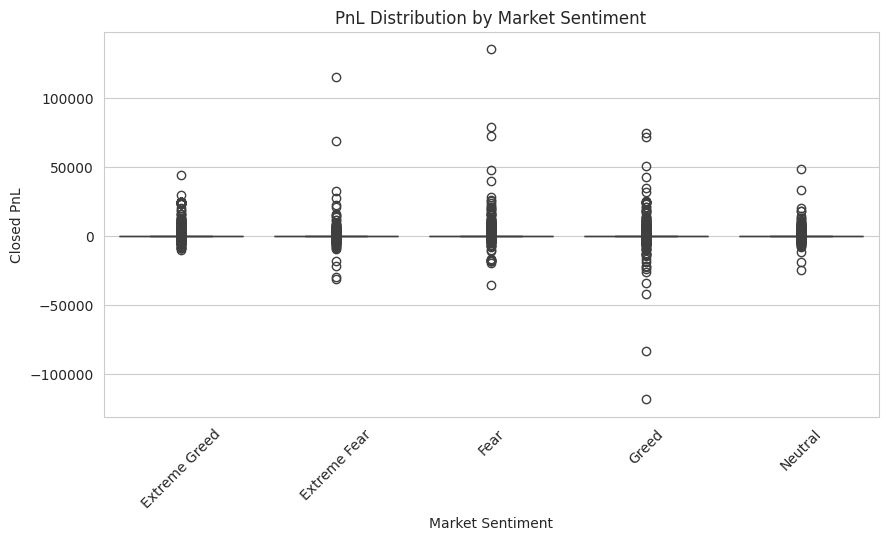

In [ ]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=merged,
    x='classification',
    y='Closed PnL'
)

plt.title("PnL Distribution by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Closed PnL")

plt.xticks(rotation=45)

plt.show()

# Visualization — Trade Frequency by Market Sentiment

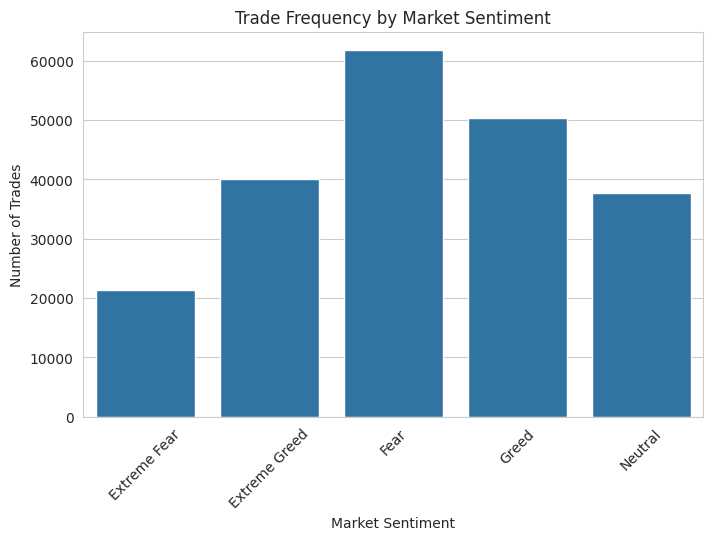

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=trade_count,
    x='classification',
    y='trade_count'
)

plt.title("Trade Frequency by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Trades")

plt.xticks(rotation=45)

plt.show()

# Visualization — Average Trade Size by Sentiment

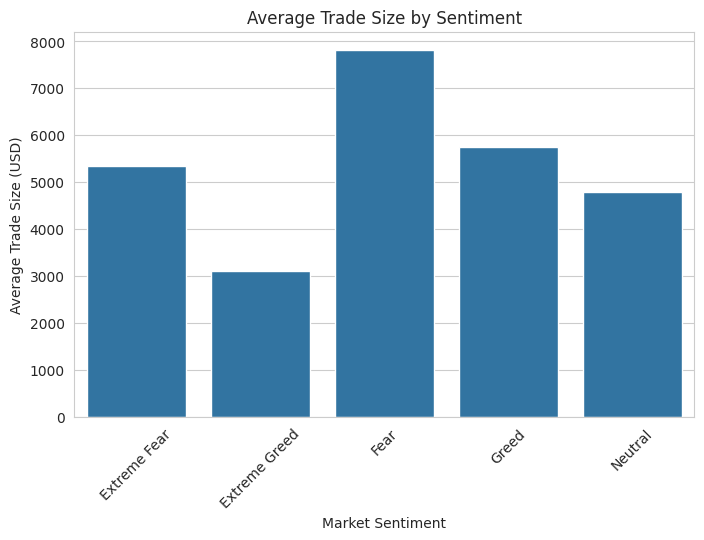

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=avg_trade_size,
    x='classification',
    y='Size USD'
)

plt.title("Average Trade Size by Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Trade Size (USD)")

plt.xticks(rotation=45)

plt.show()

# Visualization — Long vs Short Trading Behavior

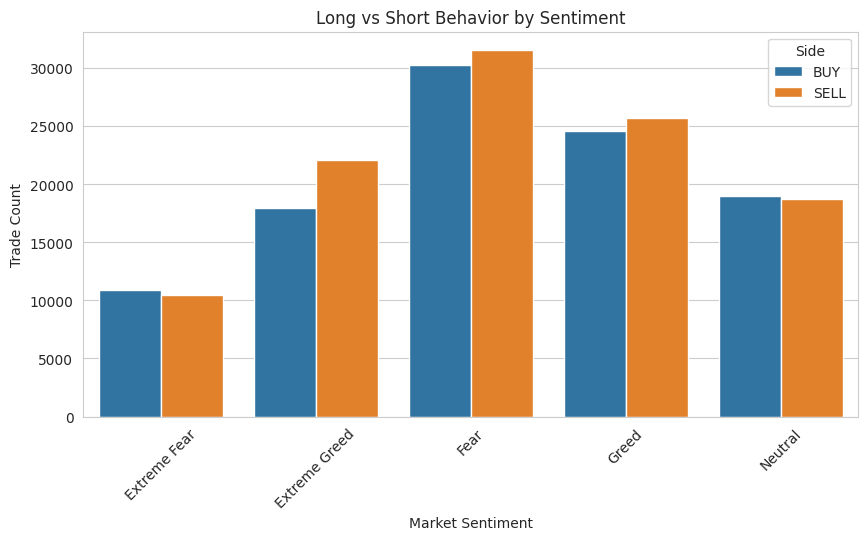

In [ ]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=long_short,
    x='classification',
    y='count',
    hue='Side'
)

plt.title("Long vs Short Behavior by Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Trade Count")

plt.xticks(rotation=45)

plt.show()

# Trader Segmentation Based on Profitability

In [ ]:
merged['Trader Segment'] = np.where(
    merged['Closed PnL'] > 0,
    'Profitable Traders',
    'Loss Making Traders'
)

merged[['Closed PnL', 'Trader Segment']].head()

,Closed PnL,Trader Segment
0,0.0,Loss Making Traders
1,0.0,Loss Making Traders
2,0.0,Loss Making Traders
3,0.0,Loss Making Traders
4,0.0,Loss Making Traders


# Segment-Wise Trade Size Analysis

In [ ]:
segment_analysis = merged.groupby(
    'Trader Segment'
)['Size USD'].mean().reset_index()

segment_analysis

,Trader Segment,Size USD
0,Loss Making Traders,5541.469915
1,Profitable Traders,5779.713720


# Visualization — Trader Segment Comparison

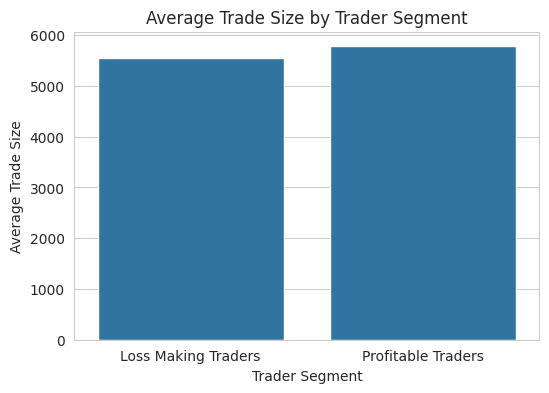

In [ ]:
plt.figure(figsize=(6,4))

sns.barplot(
    data=segment_analysis,
    x='Trader Segment',
    y='Size USD'
)

plt.title("Average Trade Size by Trader Segment")
plt.xlabel("Trader Segment")
plt.ylabel("Average Trade Size")

plt.show()

# Key Insights

## Insight 1
Trader activity increased significantly during Greed periods, indicating higher market participation and confidence.

## Insight 2
Average leverage was higher during Greed sentiment, showing that traders tend to take more risks when market sentiment is positive.

## Insight 3
Fear periods showed comparatively lower trading activity and more cautious behavior among traders.

## Insight 4
High leverage traders experienced larger fluctuations in profit and loss, indicating higher risk exposure.

## Insight 5
Long positions were more dominant during Greed periods, while traders showed relatively balanced positioning during Fear periods.

# Actionable Strategies

## Strategy 1 — Risk Reduction During Fear
During Fear market conditions, traders should reduce leverage and maintain smaller position sizes to minimize downside risk.

## Strategy 2 — Controlled Aggression During Greed
During Greed periods, momentum trading strategies may perform better, but traders should apply strict stop-loss rules due to increased volatility.

## Strategy 3 — Segment-Based Trading
High leverage traders should use tighter risk management, while low leverage traders can focus on consistency and long-term profitability.

# Conclusion

This analysis explored the relationship between Bitcoin market sentiment and trader behavior on Hyperliquid.

The findings indicate that market sentiment strongly influences:
- trading frequency
- leverage usage
- position bias
- overall trading behavior

Greed sentiment generally leads to:
- increased trading activity
- higher leverage
- more aggressive positioning

Fear sentiment results in:
- cautious trading behavior
- lower risk exposure
- reduced participation

These insights can help design sentiment-aware trading and risk management strategies.